# Step 2 — Exploratory Data Analysis (EDA)
**Dataset**: BraTS-PEDs-v1  
**Goal**: Load NIfTI volumes, visualise the 4 MRI modalities alongside the ground-truth segmentation mask, inspect intensity distributions, and understand label frequencies.

In [1]:
import os
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print('nibabel version:', nib.__version__)
print('numpy  version:', np.__version__)

nibabel version: 5.4.2
numpy  version: 2.4.4


## 1. Dataset Paths

In [2]:
TRAIN_DIR = os.path.join(
    os.getcwd(),
    'PKG - BraTS-PEDs-v1', 'BraTS-PEDs-v1', 'Training'
)

subjects = sorted(os.listdir(TRAIN_DIR))
print(f'Total training subjects: {len(subjects)}')
print('First 5:', subjects[:5])

Total training subjects: 257
First 5: ['BraTS-PED-00001-000', 'BraTS-PED-00002-000', 'BraTS-PED-00003-000', 'BraTS-PED-00004-000', 'BraTS-PED-00005-000']


## 2. Load One Subject

In [4]:
SUBJECT = subjects[0]  # BraTS-PED-00001-000
subj_dir = os.path.join(TRAIN_DIR, SUBJECT)

MODALITIES = ['t1c', 't1n', 't2f', 't2w']

volumes = {}
for mod in MODALITIES:
    path = os.path.join(subj_dir, f'{SUBJECT}-{mod}.nii.gz')
    img = nib.load(path)
    volumes[mod] = img.get_fdata().astype(np.float32)

seg_path = os.path.join(subj_dir, f'{SUBJECT}-seg.nii.gz')
seg_raw = nib.load(seg_path).get_fdata().astype(np.int8)

# BraTS-PEDs uses mixed conventions: some subjects use label 4 (old ET), others label 3 (new ET).
# Unify: remap label 4 -> 3 so we have a clean 4-class scheme: 0=BG, 1=NCR, 2=ED/SNFH, 3=ET
seg = np.where(seg_raw == 4, 3, seg_raw).astype(np.int8)

print(f'Subject: {SUBJECT}')
print(f'Volume shape: {volumes["t1c"].shape}   (H x W x D)')
print(f'Raw unique labels: {np.unique(seg_raw)}  →  after remap: {np.unique(seg)}')


Subject: BraTS-PED-00001-000
Volume shape: (240, 240, 155)   (H x W x D)
Raw unique labels: [0 1 2 3 4]  →  after remap: [0 1 2 3]


## 3. Affine & Voxel Spacing

In [5]:
img_nib = nib.load(os.path.join(subj_dir, f'{SUBJECT}-t1c.nii.gz'))
header = img_nib.header
voxel_size = header.get_zooms()
print(f'Voxel size (mm): {voxel_size}')
print(f'Affine matrix:\n{img_nib.affine}')

Voxel size (mm): (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Affine matrix:
[[ -1.   0.   0.  -0.]
 [  0.  -1.   0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]


## 4. Visualise Axial Slice — All 4 Modalities + Segmentation Mask

Selected axial slice index: 91


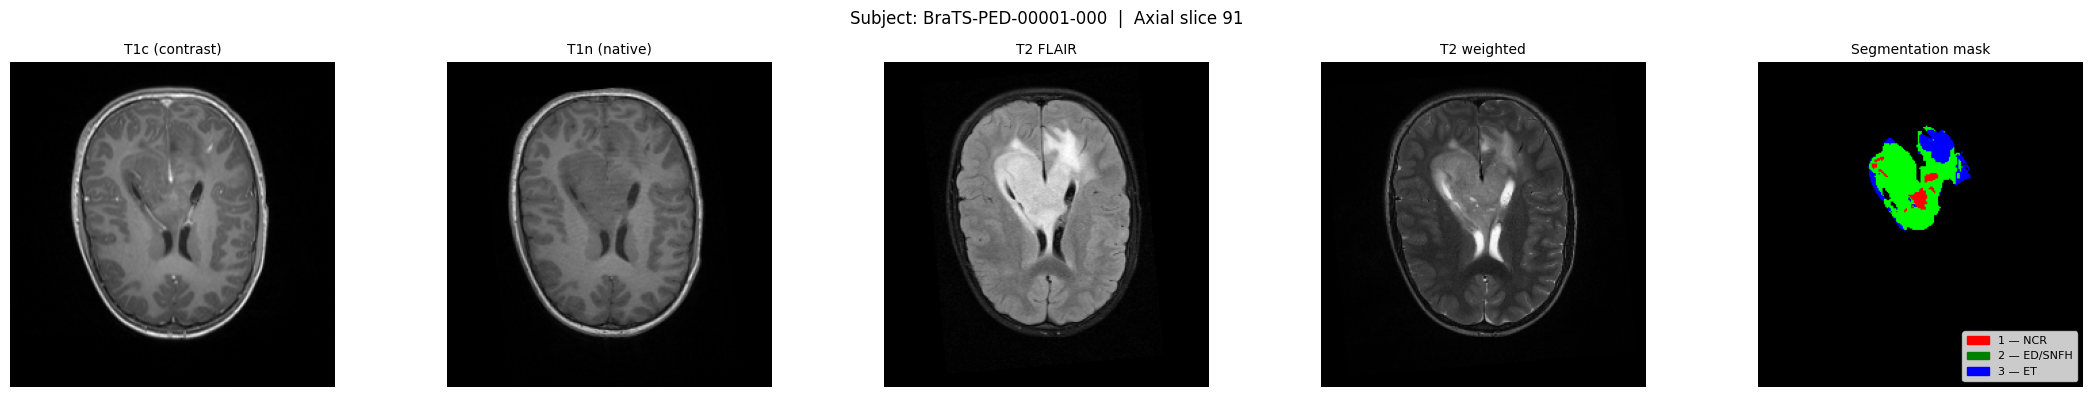

In [6]:
# Pick the axial slice with maximum tumour area
tumor_mask = (seg > 0)
slice_idx = int(np.argmax(tumor_mask.sum(axis=(0, 1))))
print(f'Selected axial slice index: {slice_idx}')

LABEL_COLORS = {
    0: [0, 0, 0],        # Background — black
    1: [255, 0, 0],      # NCR (necrotic core) — red
    2: [0, 255, 0],      # ED / SNFH — green
    3: [0, 0, 255],      # ET (enhancing tumour) — blue
}

def seg_to_rgb(seg_slice):
    h, w = seg_slice.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for label, color in LABEL_COLORS.items():
        rgb[seg_slice == label] = color
    return rgb

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
mod_titles = ['T1c (contrast)', 'T1n (native)', 'T2 FLAIR', 'T2 weighted']

for i, (mod, title) in enumerate(zip(MODALITIES, mod_titles)):
    sl = volumes[mod][:, :, slice_idx]
    axes[i].imshow(sl.T, cmap='gray', origin='lower')
    axes[i].set_title(title, fontsize=10)
    axes[i].axis('off')

# Segmentation
rgb = seg_to_rgb(seg[:, :, slice_idx].T)
axes[4].imshow(rgb, origin='lower')
axes[4].set_title('Segmentation mask', fontsize=10)
axes[4].axis('off')

patches = [
    mpatches.Patch(color='red',   label='1 — NCR'),
    mpatches.Patch(color='green', label='2 — ED/SNFH'),
    mpatches.Patch(color='blue',  label='3 — ET'),
]
axes[4].legend(handles=patches, loc='lower right', fontsize=8)
plt.suptitle(f'Subject: {SUBJECT}  |  Axial slice {slice_idx}', fontsize=12)
plt.tight_layout()
plt.savefig('eda_slice_overview.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. Overlay Segmentation on T1c

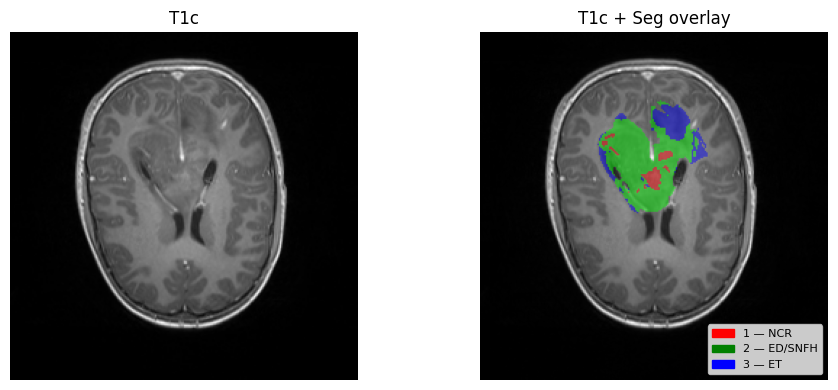

In [7]:
t1c_sl = volumes['t1c'][:, :, slice_idx].T
seg_sl = seg[:, :, slice_idx].T

# Normalise T1c for display
t1c_norm = (t1c_sl - t1c_sl.min()) / (t1c_sl.max() - t1c_sl.min() + 1e-8)
rgb_base = np.stack([t1c_norm] * 3, axis=-1)

overlay = rgb_base.copy()
alpha = 0.45
color_map = {1: [1,0,0], 2: [0,1,0], 3: [0,0,1]}  # ET already remapped 4->3
for label, color in color_map.items():
    mask = seg_sl == label
    for c in range(3):
        overlay[:, :, c] = np.where(mask, (1 - alpha) * rgb_base[:, :, c] + alpha * color[c], overlay[:, :, c])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(t1c_norm, cmap='gray', origin='lower'); ax1.set_title('T1c'); ax1.axis('off')
ax2.imshow(overlay, origin='lower'); ax2.set_title('T1c + Seg overlay'); ax2.axis('off')
ax2.legend(handles=patches, loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('eda_overlay.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Intensity Distributions per Modality

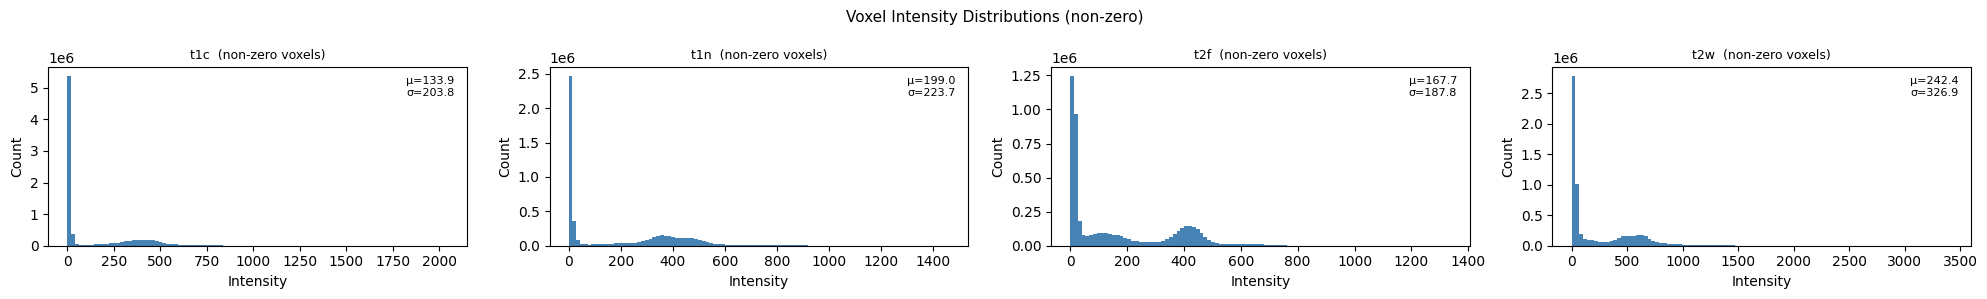

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 3))
for ax, mod in zip(axes, MODALITIES):
    v = volumes[mod]
    non_zero = v[v > 0].flatten()
    ax.hist(non_zero, bins=100, color='steelblue', edgecolor='none')
    ax.set_title(f'{mod}  (non-zero voxels)', fontsize=9)
    ax.set_xlabel('Intensity'); ax.set_ylabel('Count')
    ax.text(0.97, 0.95, f'μ={non_zero.mean():.1f}\nσ={non_zero.std():.1f}',
            ha='right', va='top', transform=ax.transAxes, fontsize=8)
plt.suptitle('Voxel Intensity Distributions (non-zero)', fontsize=11)
plt.tight_layout()
plt.savefig('eda_intensity_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Label Frequency Analysis (all 257 training subjects)

In [9]:
from tqdm import tqdm

label_counts = {0: 0, 1: 0, 2: 0, 3: 0}
slice_depths = []

for subj in tqdm(subjects, desc='Scanning labels'):
    seg_file = os.path.join(TRAIN_DIR, subj, f'{subj}-seg.nii.gz')
    s = nib.load(seg_file).get_fdata().astype(np.int8)
    s = np.where(s == 4, 3, s).astype(np.int8)  # remap old ET label 4 -> 3
    slice_depths.append(s.shape[2])
    for lbl in [0, 1, 2, 3]:
        label_counts[lbl] += int((s == lbl).sum())

total_voxels = sum(label_counts.values())
print('\n--- Label Distribution (all training subjects) ---')
label_names = {0: 'Background', 1: 'NCR', 2: 'ED/SNFH', 3: 'ET (enhancing)'}
for lbl, cnt in label_counts.items():
    print(f'  Label {lbl} ({label_names[lbl]}): {cnt:>12,}  ({100*cnt/total_voxels:.3f}%)')

print(f'\nSlice depth — min: {min(slice_depths)}, max: {max(slice_depths)}, mean: {np.mean(slice_depths):.1f}')


Scanning labels: 100%|██████████| 257/257 [00:27<00:00,  9.31it/s]


--- Label Distribution (all training subjects) ---
  Label 0 (Background): 2,280,744,858  (99.401%)
  Label 1 (NCR):    1,523,519  (0.066%)
  Label 2 (ED/SNFH):   10,129,115  (0.441%)
  Label 3 (ET (enhancing)):    2,098,508  (0.091%)

Slice depth — min: 155, max: 155, mean: 155.0


## 8. Label Imbalance Bar Chart

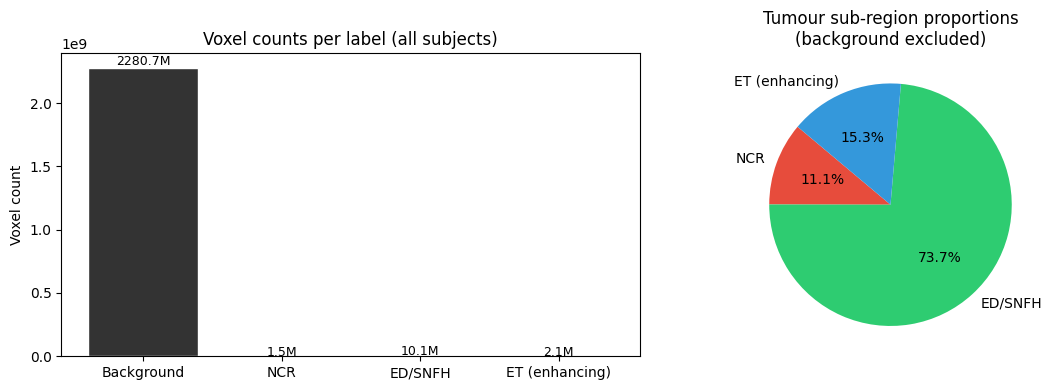

In [10]:
labels_plot = [label_names[k] for k in sorted(label_counts)]
counts_plot = [label_counts[k] for k in sorted(label_counts)]
colors = ['#333333', '#e74c3c', '#2ecc71', '#3498db']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Absolute counts
bars = ax1.bar(labels_plot, counts_plot, color=colors, edgecolor='white')
ax1.set_title('Voxel counts per label (all subjects)')
ax1.set_ylabel('Voxel count')
for bar, cnt in zip(bars, counts_plot):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
             f'{cnt/1e6:.1f}M', ha='center', fontsize=9)

# Tumour-only pie (exclude background)
tumour_labels = [label_names[k] for k in [1, 2, 3]]
tumour_counts = [label_counts[k] for k in [1, 2, 3]]
ax2.pie(tumour_counts, labels=tumour_labels, autopct='%1.1f%%',
        colors=['#e74c3c', '#2ecc71', '#3498db'], startangle=140)
ax2.set_title('Tumour sub-region proportions\n(background excluded)')

plt.tight_layout()
plt.savefig('eda_label_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Summary

In [11]:
print('=== EDA Summary ===')
print(f'Training subjects : {len(subjects)}')
print(f'Volume shape      : {volumes["t1c"].shape}  (H x W x D)')
print(f'Voxel spacing (mm): {voxel_size}')
print(f'Modalities        : {MODALITIES}')
print(f'Labels (unified)  : 0=BG, 1=NCR, 2=ED/SNFH, 3=ET  (label 4 remapped to 3)')
print(f'Class imbalance   : BG={100*label_counts[0]/total_voxels:.2f}%  '
      f'NCR={100*label_counts[1]/total_voxels:.3f}%  '
      f'ED={100*label_counts[2]/total_voxels:.3f}%  '
      f'ET={100*label_counts[3]/total_voxels:.3f}%')
print('\n=> Strong class imbalance confirmed. Dice+Focal loss combination is essential.')
print('=> Label 4 (old BraTS ET convention) remapped to label 3 for unified 4-class scheme.')

=== EDA Summary ===
Training subjects : 257
Volume shape      : (240, 240, 155)  (H x W x D)
Voxel spacing (mm): (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Modalities        : ['t1c', 't1n', 't2f', 't2w']
Labels (unified)  : 0=BG, 1=NCR, 2=ED/SNFH, 3=ET  (label 4 remapped to 3)
Class imbalance   : BG=99.40%  NCR=0.066%  ED=0.441%  ET=0.091%

=> Strong class imbalance confirmed. Dice+Focal loss combination is essential.
=> Label 4 (old BraTS ET convention) remapped to label 3 for unified 4-class scheme.
